#  Модуль 7. Преобразование распределений признаков

## Подробный конспект

### 7.1. Зачем преобразовывать распределения

Многие признаки в реальных данных имеют **неудобную форму**:
- Доходы скошены вправо: большинство получают мало, а миллионеры тянут хвост
- Время на сайте: большинство проводят минуты, но кто-то — сутки
- Цены на жильё: в логарифме выглядят симметричнее, чем в рублях

**Проблема:** модели видят числа, но «чувствуют» их по-разному.
- Алгоритмы на расстояниях (KNN, KMeans, SVM) воспринимают длинный хвост как «далеко» и доминирующим образом учитывают экстремальные значения.
- Линейные модели и нейросети с градиентным спуском сходятся быстрее, когда данные симметричны и одного масштаба.
- Деревья менее чувствительны, но биннинг может им помочь уловить нелинейность.

**Цель трансформации:** сделать распределение более симметричным, приблизить к нормальному, уменьшить влияние хвостов.

### 7.2. Почему модели любят нормальные распределения

**Важное уточнение:** не все модели требуют нормальности **признаков**. Но почти все выигрывают от симметрии и отсутствия экстремальных хвостов.

| Тип модели | Почему важна форма распределения |
|-----------|----------------------------------|
| **Линейная регрессия** | Предполагается нормальность **ошибок**, но симметричные признаки дают более стабильные коэффициенты |
| **Логистическая регрессия, SVM** | Градиентный спуск быстрее сходится на симметричных данных; выбросы тянут разделяющую границу |
| **KNN, KMeans** | Расстояния искажаются, если один признак имеет огромный разброс |
| **Нейросети** | Симметричные входы -> более гладкий ландшафт функции потерь; меньше шанс застрять в плохом минимуме |
| **Деревья, бустинги** | Меньше чувствительны, но биннинг может улучшить интерпретацию |

**Практическое правило:** если признак сильно скошен (skewness > 1 или < −1) — имеет смысл трансформировать.

### 7.3. Логарифмическое преобразование

Самый популярный и чаще всего самый эффективный метод. **Сжимает правый хвост** и **растягивает левый**.

#### Как работает

Если у вас есть числа от 1 до 1 000 000:
- `log(1) = 0`
- `log(10) ≈ 2.3`
- `log(1000) ≈ 6.9`
- `log(1000000) ≈ 13.8`

Разница между 1 и 10 — огромная в абсолютных числах, но маленькая в логарифмах. Разница между 1000 и 1 000 000 тоже в 1000 раз, но в логарифмах это всего лишь 6.9 против 13.8.

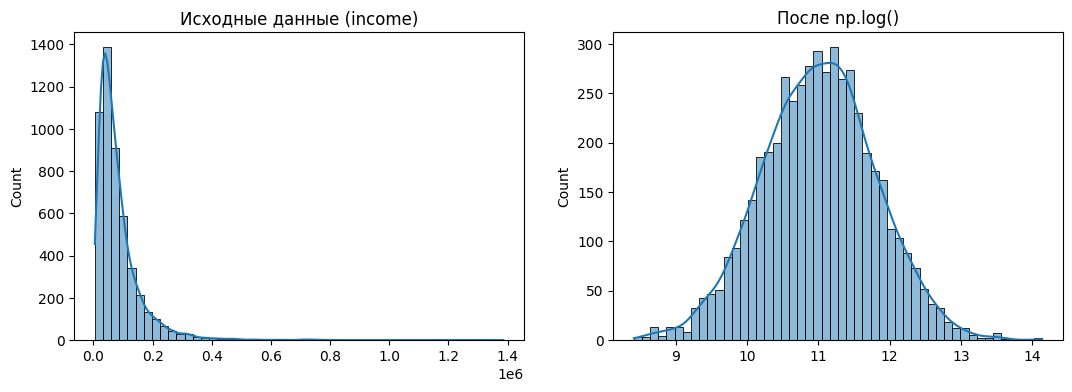

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

# Создадим логнормальное распределение (доходы)
income = np.random.lognormal(mean=11, sigma=0.8, size=5000)

fig, axes = plt.subplots(1, 2, figsize=(12.75, 4))

# До
sns.histplot(income, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Исходные данные (income)')

# После логарифма
sns.histplot(np.log(income), bins=50, kde=True, ax=axes[1])
axes[1].set_title('После np.log()')

plt.show()

#### Проблема нулей: `np.log1p`

`np.log(0)` = минус бесконечность (`-inf`). Если в данных есть нули, обычный логарифм сломается.

Решение: `log1p(x) = log(1 + x)`

In [3]:
# Пример с нулями
number_of_orders = [0, 1, 2, 5, 10, 50, 100]

# Обычный логарифм даст -inf для 0
print(np.log(0))  # -inf

# log1p безопасен
print(np.log1p(number_of_orders))
# [0.         0.69314718 1.09861229 1.79175947 2.39789527 3.93182563 4.61512052]

-inf
[0.         0.69314718 1.09861229 1.79175947 2.39789527 3.93182563
 4.61512052]


C:\Users\igory\AppData\Local\Temp\ipykernel_16952\1793205582.py:5: RuntimeWarning: divide by zero encountered in log
  print(np.log(0))  # -inf


**Когда использовать логарифм:**
- Доходы, цены, площади, население (всё, что ≥ 0 и скошено вправо)
- Время выполнения операции
- «Тяжёлые хвосты» вправо

**Когда НЕ использовать:**
- Данные с отрицательными значениями (без сдвига)
- Бимодальные распределения (логарифм не исправит два пика)
- Данные, которые уже симметричны

#### Обратная трансформация

Если вы предсказываете в логарифмах, результат нужно перевести обратно:

In [ ]:
# Предсказание модели в логарифмах
y_pred_log = model.predict(X_test)

# Обратно в рубли
y_pred = np.expm1(y_pred_log)  # exp(x) - 1, обратная к log1p
# или просто np.exp(y_pred_log), если использовали np.log

### 7.4. Квадратный корень

Более **мягкое** преобразование, чем логарифм. Подходит для **счётных данных** (количество звонков, посетителей, товаров), где нули часты, а логарифм был бы слишком агрессивен.

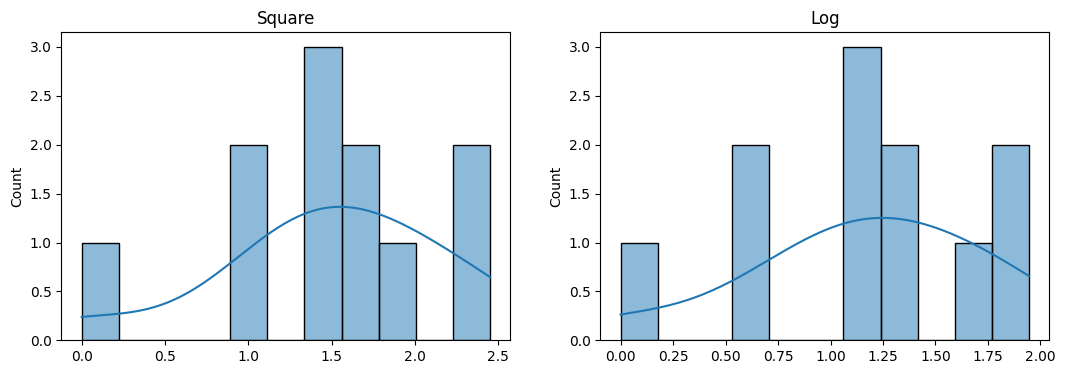

In [5]:
# Пример: количество детей в семье
children = [0, 1, 1, 2, 2, 2, 3, 3, 4, 5, 6]

# Корень
square = np.sqrt(children)
loga = np.log1p(children)
# [0. , 1. , 1. , 1.41, 1.41, 1.41, 1.73, 1.73, 2. , 2.24, 2.45]

# Логарифм сжал бы слишком сильно
# log1p: [0. , 0.69, 0.69, 1.1, 1.1, 1.1, 1.39, 1.39, 1.61, 1.79, 1.95]

fig, axes = plt.subplots(1, 2, figsize=(12.75, 4))
sns.histplot(square, bins=11, kde=True, ax=axes[0])
axes[0].set_title('Square')

sns.histplot(loga, bins=11, kde=True, ax=axes[1])
axes[1].set_title('Log')

plt.show()

**Когда использовать:** данные с небольшими целыми числами, много нулей, правый хвост не очень длинный.

### 7.5. Обратное преобразование

$$X_{new} = \frac{1}{X}$$

**Смысл:** переводит «время между событиями» в «частоту событий». Очень сильно сжимает большие значения.

In [ ]:
# Время между заказами (в часах)
time_between_orders = [1, 2, 5, 10, 24, 48, 168]  # от 1 часа до недели

# Частота заказов (заказов в час)
частота = 1 / np.array(time_between_orders)
# [1.    , 0.5   , 0.2   , 0.1   , 0.0417, 0.0208, 0.006 ]

**Опасность:** если в данных есть нули — деление на ноль. Нужно сдвигать: `1 / (X + c)`.

### 7.6. Степенные преобразования

Это семейство методов, которое автоматически подбирает **степень** (параметр λ), наилучшим образом приближающую данные к нормальному распределению.

#### Box-Cox

**Формула:**
$$
y = \begin{cases}
\frac{x^\lambda - 1}{\lambda}, & \lambda \neq 0 \\
\ln(x), & \lambda = 0
\end{cases}
$$

**Критическое ограничение:** работает **только со строго положительными** данными (x > 0). Нули и отрицательные числа недопустимы.

Оптимальный lambda: -0.083


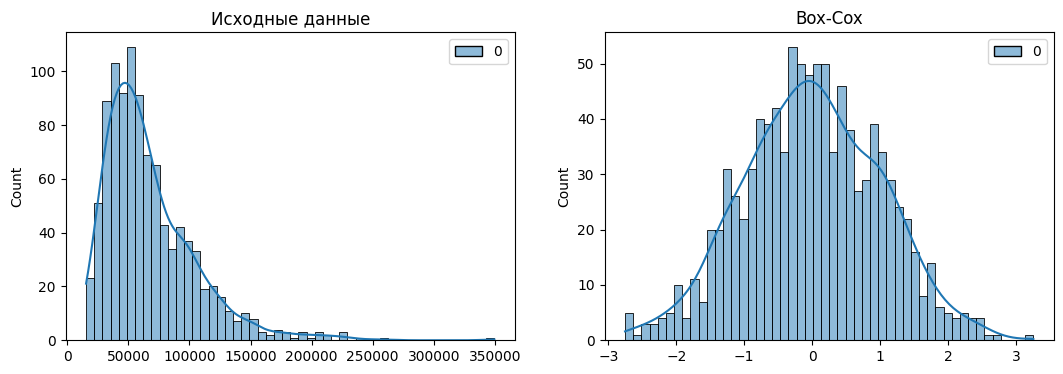

In [7]:
from sklearn.preprocessing import PowerTransformer
import numpy as np

# Данные > 0
income = np.random.lognormal(11, 0.5, 1000).reshape(-1, 1)

# Box-Cox
pt_boxcox = PowerTransformer(method='box-cox', standardize=True)
income_boxcox = pt_boxcox.fit_transform(income)

print(f"Оптимальный lambda: {pt_boxcox.lambdas_[0]:.3f}")

# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(12.75, 4))
sns.histplot(income, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Исходные данные')
sns.histplot(income_boxcox, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Box-Cox')
plt.show()

**Интерпретация λ:**
- λ ≈ 1 — данные уже почти нормальны (преобразование близко к линейному)
- λ ≈ 0 — эквивалентно логарифму
- λ ≈ 0.5 — эквивалентно квадратному корню
- λ ≈ −1 — эквивалентно обратному преобразованию

#### Yeo-Johnson

Расширение Box-Cox, которое работает с **любыми числами**: положительными, отрицательными и нулём.

Оптимальный lambda: 0.926


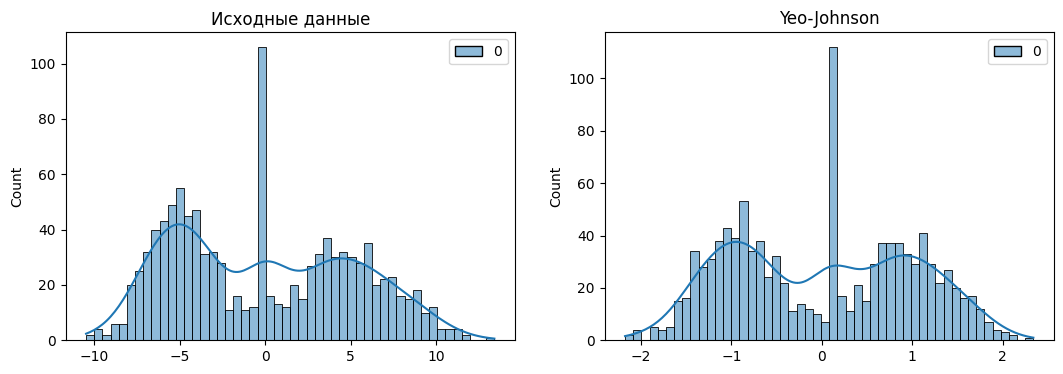

In [11]:
# Данные с нулями и отрицательными значениями (например, температурные аномалии)
income = np.concatenate([
    np.random.normal(-5, 2, 500),
    np.random.normal(5, 3, 500),
    [0] * 100
]).reshape(-1, 1)

pt_yj = PowerTransformer(method='yeo-johnson', standardize=True)
income_yj = pt_yj.fit_transform(income)

print(f"Оптимальный lambda: {pt_yj.lambdas_[0]:.3f}")

fig, axes = plt.subplots(1, 2, figsize=(12.75, 4))
sns.histplot(income, bins=50, kde=True, ax=axes[0])
axes[0].set_title('Исходные данные')
sns.histplot(income_yj, bins=50, kde=True, ax=axes[1])
axes[1].set_title('Yeo-Johnson')

plt.show()

**Когда что использовать:**

| Условие | Метод |
|---------|-------|
| Данные строго > 0 | Box-Cox |
| Данные ≥ 0 или смешанные знаки | Yeo-Johnson |
| Не хочется думать о знаках | Yeo-Johnson (безопаснее) |

> **Важно:** `PowerTransformer` по умолчанию **стандартизирует** результат (среднее ≈ 0, std ≈ 1). Это удобно, но если вам нужно только изменить форму — помните об этом.

### 7.7. Биннинг (Binning / Discretization)

Биннинг — это преобразование **числового** признака в **категориальный**: мы делим диапазон значений на интервалы (бины) и заменяем число номером интервала.

**Зачем:**
- **Устойчивость к выбросам:** выброс попадает в крайний бин и перестаёт доминировать
- **Нелинейность:** модель учит не точное значение, а «высокий/средний/низкий», что иногда полезнее
- **Интерпретируемость:** «клиент старше 60» понятнее, чем «возраст = 63.5»
- **Работа с редкими значениями:** слишком детальные числа сшиваются в группы

#### Тип 1: Равноширокие интервалы (Uniform)

Диапазон делится на N равных частей.

In [12]:
# Пример: возраст от 18 до 90, 5 бинов
# [18–32), [32–46), [46–60), [60–74), [74–90]

age = [22, 35, 48, 55, 67, 81]

# pandas cut
bins = pd.cut(age, bins=5, labels=['молодой', 'молодой+', 'средний', 'старший', 'пожилой'])
print(bins)

['молодой', 'молодой+', 'средний', 'средний', 'старший', 'пожилой']
Categories (5, str): ['молодой' < 'молодой+' < 'средний' < 'старший' < 'пожилой']


**Проблема:** если данные скошены, большинство наблюдений свалится в 1–2 бина, а остальные будут почти пустыми.

#### Тип 2: Квантильное разбиение (Quantile-based)

Каждый бин содержит **примерно одинаковое количество** наблюдений. Границы подстраиваются под плотность данных.

In [15]:
# qcut — квантильное разбиение
income = np.random.lognormal(11, 0.6, 1000)

# 4 квартили (квартили = 4 бина с равным числом наблюдений)
income_binned = pd.qcut(income, q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])

print(income_binned)
print()
print(income_binned.value_counts())
# Q1    250
# Q2    250
# Q3    250
# Q4    250

['Q2', 'Q3', 'Q1', 'Q1', 'Q2', ..., 'Q3', 'Q3', 'Q2', 'Q3', 'Q3']
Length: 1000
Categories (4, str): ['Q1' < 'Q2' < 'Q3' < 'Q4']

Q1    250
Q2    250
Q3    250
Q4    250
Name: count, dtype: int64


**Проблема:** границы могут быть «страшными» (не круглыми числами), и близкие по значению точки могут попасть в разные бины из-за плотности.

#### Тип 3: KMeans-биннинг

Границы бинов определяются кластеризацией KMeans по одному признаку. Бины получаются там, где естественные «скопления» данных.

In [38]:
from sklearn.preprocessing import KBinsDiscretizer

income_reshaped = income.reshape(-1, 1)

# KMeans-биннинг на 4 бина
kbd = KBinsDiscretizer(n_bins=4, encode='ordinal', strategy='kmeans')
income_kmeans = kbd.fit_transform(income_reshaped)

print(income_kmeans.T[:, 150:174])
print()
print(f"Границы бинов: {kbd.bin_edges_[0]}")

[[1. 1. 0. 1. 0. 1. 0. 2. 0. 1. 0. 0. 0. 1. 0. 0. 1. 0. 0. 3. 0. 1. 0. 1.]]

Границы бинов: [  9418.79740035  69317.76589889 136154.33189252 269724.88439355
 468525.72423481]


**Преимущество:** учитывает плотность данных лучше, чем равноширокие бины.  
**Недостаток:** медленнее; случайная инициализация может давать разные границы.

#### Плюсы и минусы биннинга

| Плюсы | Минусы |
|-------|--------|
| Устойчивость к выбросам | Потеря информации (внутри бина все равны) |
| Простота интерпретации | Сложно подобрать оптимальное число бинов |
| Работает с деревьями | Проблема с новыми данными (выход за границы обучающей выборки) |
| Может улучшить линейные модели, если связь нелинейная | Если связь линейная — теряем точность |

**Сколько бинов?**
- Слишком мало (2–3) — грубо, много потерь
- Слишком много (>20) — почти как исходные данные, но с потерей точности
- **Золотая середина:** 5–10 для интерпретации, 10–20 для сложных зависимостей

### 7.8. Сравнение всех методов

| Метод | Сила сжатия | Работает с 0 | Работает с <0 | Сохраняет порядок | Когда использовать |
|-------|-------------|------------|---------------|-------------------|-------------------|
| **Логарифм** | Сильная | log1p да | Нет | Да | Доходы, цены, время (правый хвост) |
| **Корень** | Средняя | Да | Нет | Да | Счётные данные, мягкое сжатие |
| **Обратное** | Очень сильная | Нет (сдвиг) | Нет | Да (но перевёрнутое) | Частота, обратные величины |
| **Box-Cox** | Автоматическая | Нет | Нет | Да | Нужна нормальность, данные > 0 |
| **Yeo-Johnson** | Автоматическая | Да | Да | Да | Нужна нормальность, любые числа |
| **Биннинг** | — | Да | Да | Нет (категории) | Устойчивость к выбросам, интерпретация |

### 7.9. Практический пример: полный цикл трансформации

Исходная асимметрия:
доход      2.48
возраст    0.20
заказы     0.58
dtype: float64


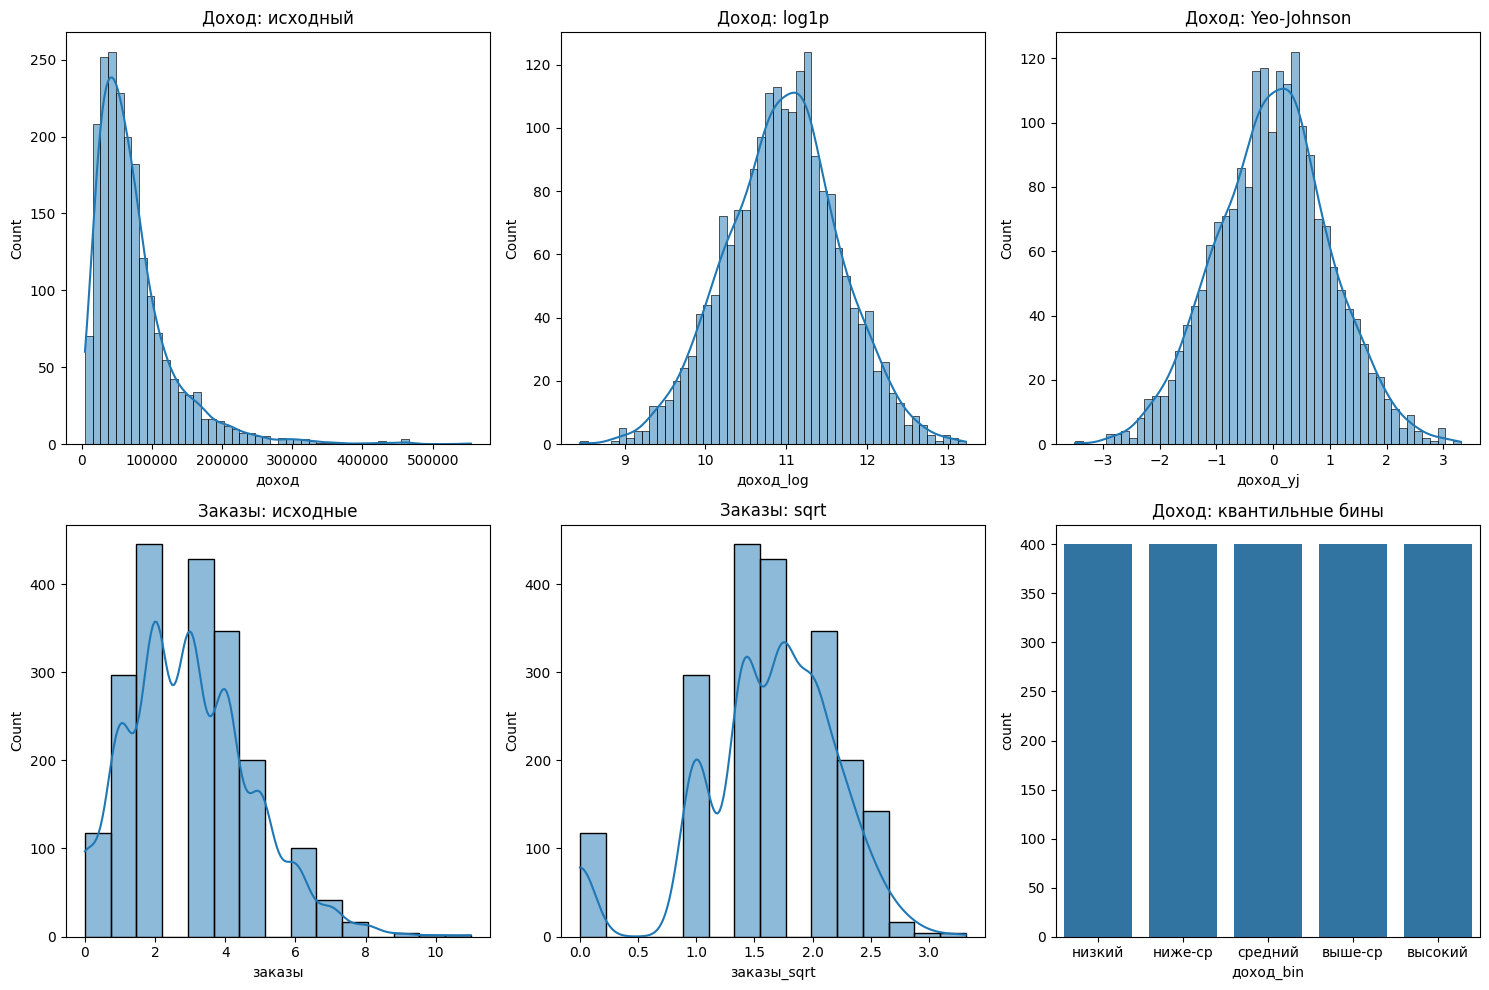


Асимметрия после трансформаций:
Доход log1p:       -0.048
Доход Yeo-Johnson: 0.000
Заказы sqrt:       -0.784

Новые данные после Yeo-Johnson: [-0.20964429  1.37190697  2.39025374]


C:\Users\igory\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but PowerTransformer was fitted with feature names
  warnings.warn(


In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import PowerTransformer
from sklearn.preprocessing import KBinsDiscretizer

rng = np.random.default_rng(seed=42)

# Создаём скошенные данные
df = pd.DataFrame({
    'доход': rng.lognormal(11, 0.7, 2000),  # сильный правый хвост
    'возраст': rng.normal(40, 12, 2000).clip(18, 90).astype(int),
    'заказы': rng.poisson(3, 2000)  # счётные данные
})

print("Исходная асимметрия:")
print(df[['доход', 'возраст', 'заказы']].skew().round(2))
# доход    ~2.48 (сильно скошен)
# возраст  ~0.2 (почти симметричен)
# заказы   ~0.58 (умеренно скошен)

# === ТРАНСФОРМАЦИИ ===

# 1. Логарифм дохода
df['доход_log'] = np.log1p(df['доход'])

# 2. Корень от заказов
df['заказы_sqrt'] = np.sqrt(df['заказы'])

# 3. Yeo-Johnson (универсальный)
pt = PowerTransformer(method='yeo-johnson')
df['доход_yj'] = pt.fit_transform(df[['доход']])

# 4. Биннинг дохода на квантили
df['доход_bin'] = pd.qcut(df['доход'], q=5, labels=['низкий', 'ниже-ср', 'средний', 'выше-ср', 'высокий'])

# === ВИЗУАЛИЗАЦИЯ ===
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Исходный доход
sns.histplot(df['доход'], bins=50, kde=True, ax=axes[0, 0])
axes[0, 0].set_title('Доход: исходный')

# Логарифм
sns.histplot(df['доход_log'], bins=50, kde=True, ax=axes[0, 1])
axes[0, 1].set_title('Доход: log1p')

# Yeo-Johnson
sns.histplot(df['доход_yj'], bins=50, kde=True, ax=axes[0, 2])
axes[0, 2].set_title('Доход: Yeo-Johnson')

# Заказы исходные
sns.histplot(df['заказы'], bins=15, kde=True, ax=axes[1, 0])
axes[1, 0].set_title('Заказы: исходные')

# Заказы корень
sns.histplot(df['заказы_sqrt'], bins=15, kde=True, ax=axes[1, 1])
axes[1, 1].set_title('Заказы: sqrt')

# Биннинг дохода
sns.countplot(x=df['доход_bin'], ax=axes[1, 2])
axes[1, 2].set_title('Доход: квантильные бины')

plt.tight_layout()
plt.show()

# Сравнение асимметрии после трансформаций
print("\nАсимметрия после трансформаций:")
print(f"Доход log1p:       {df['доход_log'].skew():.3f}")
print(f"Доход Yeo-Johnson: {df['доход_yj'].skew():.3f}")
print(f"Заказы sqrt:       {df['заказы_sqrt'].skew():.3f}")

# === ПРИМЕНЕНИЕ К НОВЫМ ДАННЫМ (важно!) ===
# PowerTransformer нужно сохранять и применять через transform, а не fit_transform!
new_income = np.array([[50000], [150000], [300000]])
new_transformed = pt.transform(new_income)
print(f"\nНовые данные после Yeo-Johnson: {new_transformed.flatten()}")

### 7.10. Чек-лист для самопроверки

Перед переходом к Модулю 8 убедитесь, что вы:

- [ ] Понимаете, зачем преобразовывать распределения (симметрия, хвосты, нормальность)
- [ ] Знаете, какие модели чувствительны к скошенным данным, а какие — нет
- [ ] Можете применить `np.log()` и `np.log1p()`, знаете разницу
- [ ] Понимаете, когда логарифм не подходит (отрицательные числа, бимодальность)
- [ ] Умеете использовать квадратный корень для счётных данных
- [ ] Знаете опасность обратного преобразования при нуле
- [ ] Понимаете принцип Box-Cox и его ограничение (x > 0)
- [ ] Знаете, почему Yeo-Johnson безопаснее Box-Cox
- [ ] Умеете использовать `PowerTransformer` из sklearn и сохранять его для новых данных
- [ ] Можете объяснить, зачем нужен биннинг
- [ ] Знаете разницу между равноширокими бинами и квантильными
- [ ] Понимаете плюсы (устойчивость) и минусы (потеря информации) биннинга
- [ ] Можете выбрать подходящий метод трансформации под конкретный признак

> **Переход к Модулю 8:** Теперь, когда вы умеете преобразовывать числовые признаки, пора научиться обращаться с категориальными. Мы изучим кодирование: как перевести текст и категории в числа, понятные моделям, без потери смысла и с минимальными искажениями.